# GG-PI: Sampling Example for Water

This notebook demonstrates how to apply GG-PI to sample water at 300K with 32 beads using a pre-trained checkpoint.

**System:**
- 216 water molecules
- Temperature: 300K
- Beads: 32
- Box: Periodic cubic box

In [1]:
# =============================================================================
# Import Dependencies
# =============================================================================
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt
import pickle

# GG-PI package imports
from ggpi.nn import ViSNet_Velocity_Network
from ggpi.sampling import ConditionalFlowSampler, GibbsSampler

# Set paths
cwd = Path.cwd()
data_dir = cwd.parent / "data"
checkpoint_dir = cwd.parent / "checkpoints"

# Set random seeds for reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
# =============================================================================
# Analysis Helper Functions
# =============================================================================
import freud

def calculate_rdf_freud(pos, box_vec, r_max=15, nbins=100):
    """Calculate radial distribution function using freud."""
    if pos.ndim == 4:
        pos = pos.reshape(-1, pos.shape[-2], pos.shape[-1])
    box = freud.box.Box(Lx=box_vec[0], Ly=box_vec[1], Lz=box_vec[2])
    rdf = freud.density.RDF(r_max=r_max, bins=nbins)
    for i in range(pos.shape[0]):
        rdf.compute(system=(box, pos[i]), reset=False)
    return rdf.bin_centers, rdf.rdf


def calculate_rdf_two_types(pos1, pos2, box_vec, r_max=15, nbins=100):
    """Calculate RDF between two atom types."""
    box = freud.box.Box(Lx=box_vec[0], Ly=box_vec[1], Lz=box_vec[2])
    rdf = freud.density.RDF(r_max=r_max, bins=nbins)
    for i in range(pos1.shape[0]):
        rdf.compute(system=(box, pos1[i]), query_points=pos2[i], reset=False)
    return rdf.bin_centers, rdf.rdf


def calculate_all_rdfs(pos, Z_sys, box_vec, atomic_mapping={'O': 1, 'H': 2}, r_max=8, nbins=100, stride=1):
    """
    Calculate O-O, H-H, and O-H RDFs for water system.
    
    Args:
        pos: Position array (B, N, 3) or (B, T, N, 3)
        Z_sys: Atomic numbers array
        box_vec: Box dimensions
        atomic_mapping: Mapping of atom types to indices
        r_max: Maximum distance for RDF
        nbins: Number of bins
        stride: Frame stride
    
    Returns:
        rdf_oo, rdf_hh, rdf_oh: RDF arrays (nbins, 2)
    """
    if pos.ndim == 4:
        pos = pos.reshape(-1, pos.shape[-2], pos.shape[-1])
    if pos.ndim != 3:
        raise ValueError("Position tensor must be of shape (B, N, 3) or (B, T, N, 3)")
    pos = pos[::stride]
    
    # Extract O and H positions
    pos_O = pos[:, Z_sys == atomic_mapping['O'], :]
    pos_H = pos[:, Z_sys == atomic_mapping['H'], :]
    
    # Calculate RDFs
    r_O, g_r_O = calculate_rdf_freud(pos_O, box_vec, r_max=r_max, nbins=nbins)
    print(f"O-O RDF: {r_O.shape}")
    r_H, g_r_H = calculate_rdf_freud(pos_H, box_vec, r_max=r_max, nbins=nbins)
    print(f"H-H RDF: {r_H.shape}")
    r_OH, g_r_OH = calculate_rdf_two_types(pos_O, pos_H, box_vec, r_max=r_max, nbins=nbins)
    
    return np.column_stack((r_O, g_r_O)), np.column_stack((r_H, g_r_H)), np.column_stack((r_OH, g_r_OH))


def apply_pbc_vectorized(vecs, box_matrix):
    """Apply periodic boundary conditions to vectors."""
    inv_box = np.linalg.inv(box_matrix)
    frac_vecs = vecs @ inv_box.T
    frac_vecs = frac_vecs - np.round(frac_vecs)
    return frac_vecs @ box_matrix


def calculate_angle_between_vectors(vec1, vec2):
    """Calculate angles between pairs of vectors (vectorized)."""
    norm1 = np.linalg.norm(vec1, axis=1)
    norm2 = np.linalg.norm(vec2, axis=1)
    valid_mask = (norm1 > 0) & (norm2 > 0)
    dot_products = np.sum(vec1 * vec2, axis=1)
    cos_angles = np.zeros_like(dot_products)
    cos_angles[valid_mask] = dot_products[valid_mask] / (norm1[valid_mask] * norm2[valid_mask])
    cos_angles = np.clip(cos_angles, -1.0, 1.0)
    return np.degrees(np.arccos(cos_angles))


def calculate_hoh_angles(pos, box_vec, nbins=100, angle_start=70, angle_end=140):
    """
    Calculate H-O-H angle distribution for water molecules.
    
    Args:
        pos: Position array with O,H,H,O,H,H... pattern
        box_vec: Box dimensions
        nbins: Number of histogram bins
        angle_start, angle_end: Angle range for histogram
    
    Returns:
        Array (nbins, 2) with [angle, density]
    """
    if pos.ndim == 2:
        pos = pos[np.newaxis, :]
    elif pos.ndim == 4:
        pos = pos.reshape(-1, pos.shape[-2], pos.shape[-1])
    
    B, N, _ = pos.shape
    if N % 3 != 0:
        raise ValueError(f"Number of atoms {N} is not divisible by 3")
    
    n_molecules = N // 3
    box_matrix = np.diag(box_vec) if box_vec.ndim == 1 else box_vec
    
    # Reshape to extract O, H1, H2 positions
    pos_reshaped = pos.reshape(B * n_molecules, 3, 3)
    O_pos = pos_reshaped[:, 0, :]
    H1_pos = pos_reshaped[:, 1, :]
    H2_pos = pos_reshaped[:, 2, :]
    
    # Calculate O-H vectors with PBC
    vec_OH1 = apply_pbc_vectorized(H1_pos - O_pos, box_matrix)
    vec_OH2 = apply_pbc_vectorized(H2_pos - O_pos, box_matrix)
    
    # Calculate angles
    all_angles = calculate_angle_between_vectors(vec_OH1, vec_OH2)
    
    # Create normalized histogram
    histogram, bin_edges = np.histogram(all_angles, bins=nbins, range=(angle_start, angle_end))
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width = bin_edges[1] - bin_edges[0]
    total_area = np.sum(histogram) * bin_width
    density = histogram / total_area if total_area > 0 else histogram
    
    return np.column_stack([bin_centers, density])

## Load Reference Data

MD data: (500, 648, 3), box: [35.233 35.233 35.233]
Temperature: 300K, Units: atomic
PIMD data: (25, 32, 648, 3)
O-O RDF: (100,)
H-H RDF: (100,)
O-O RDF: (100,)
H-H RDF: (100,)


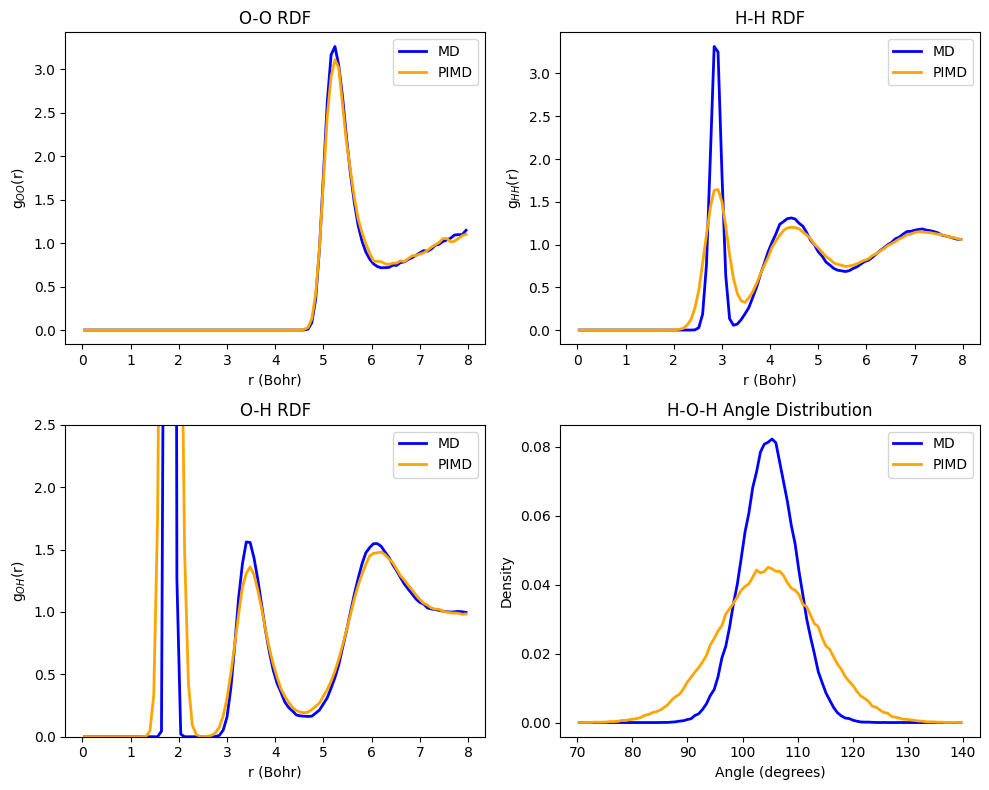

In [3]:
# =============================================================================
# Load MD and PIMD Reference Data
# =============================================================================
# Load MD reference data
data_path = data_dir / "water_md_300K.pkl"
with open(data_path, "rb") as f:
    data = pickle.load(f)

pos = np.array(data["x"])
box_size = np.array(data["box_size"])
Z = np.array(data["Z"])
prior_sigma = np.array(data['prior_sigma'])

print(f"MD data: {pos.shape}, box: {box_size}")
print(f"Temperature: {data['T']}K, Units: {data['unit']}")

# Load PIMD reference data
pimd_path = data_dir / "water_pimd_300KP32.pkl"
with open(pimd_path, "rb") as f:
    pimd_data = np.array(pickle.load(f)['x'])
print(f"PIMD data: {pimd_data.shape}")

# Calculate reference RDFs and angles
rdf_oo_md, rdf_hh_md, rdf_oh_md = calculate_all_rdfs(pos, Z, box_size)
rdf_oo_pimd, rdf_hh_pimd, rdf_oh_pimd = calculate_all_rdfs(pimd_data, Z, box_size)
angle_md = calculate_hoh_angles(pos, box_size)
angle_pimd = calculate_hoh_angles(pimd_data, box_size)

# Plot reference comparisons
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].plot(rdf_oo_md[:, 0], rdf_oo_md[:, 1], 'b-', lw=2, label='MD')
axes[0, 0].plot(rdf_oo_pimd[:, 0], rdf_oo_pimd[:, 1], 'orange', lw=2, label='PIMD')
axes[0, 0].set_xlabel('r (Bohr)')
axes[0, 0].set_ylabel('g$_{OO}$(r)')
axes[0, 0].set_title('O-O RDF')
axes[0, 0].legend()

axes[0, 1].plot(rdf_hh_md[:, 0], rdf_hh_md[:, 1], 'b-', lw=2, label='MD')
axes[0, 1].plot(rdf_hh_pimd[:, 0], rdf_hh_pimd[:, 1], 'orange', lw=2, label='PIMD')
axes[0, 1].set_xlabel('r (Bohr)')
axes[0, 1].set_ylabel('g$_{HH}$(r)')
axes[0, 1].set_title('H-H RDF')
axes[0, 1].legend()

axes[1, 0].plot(rdf_oh_md[:, 0], rdf_oh_md[:, 1], 'b-', lw=2, label='MD')
axes[1, 0].plot(rdf_oh_pimd[:, 0], rdf_oh_pimd[:, 1], 'orange', lw=2, label='PIMD')
axes[1, 0].set_xlabel('r (Bohr)')
axes[1, 0].set_ylabel('g$_{OH}$(r)')
axes[1, 0].set_title('O-H RDF')
axes[1, 0].set_ylim(0, 2.5)
axes[1, 0].legend()

axes[1, 1].plot(angle_md[:, 0], angle_md[:, 1], 'b-', lw=2, label='MD')
axes[1, 1].plot(angle_pimd[:, 0], angle_pimd[:, 1], 'orange', lw=2, label='PIMD')
axes[1, 1].set_xlabel('Angle (degrees)')
axes[1, 1].set_ylabel('Density')
axes[1, 1].set_title('H-O-H Angle Distribution')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## Load Pre-trained Model

In [4]:
# =============================================================================
# Load Pre-trained Model and Setup Sampler
# =============================================================================
checkpoint_path = checkpoint_dir / "water.pt"

model = ViSNet_Velocity_Network.load_model(checkpoint_path, device=device)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {num_params:,}")

# Compile model for faster inference (PyTorch >= 2.0)
model = torch.compile(model)

# Setup flow sampler
sampler = ConditionalFlowSampler(
    model,
    Z=torch.as_tensor(Z, dtype=torch.int64, device=device),
    prior_sigma=torch.as_tensor(prior_sigma, dtype=torch.float32, device=device),
    box_size=torch.as_tensor(box_size, dtype=torch.float32, device=device),
    device=device,
    sample_method='heun',
    fix_graph=True,
    num_steps=5,
    max_batch_size=256,
    return_cpu=False
)

# Setup Gibbs sampler
gibbs = GibbsSampler(
    sampler,
    box_size=torch.as_tensor(box_size, dtype=torch.float32, device=device),
    device=device
)

Model parameters: 79,488
ConditionalFlowSampler initialized: method=heun, steps=5, fix_graph=True
GibbsSampler initialized on cuda, cutoff=6.0, cache_interval=5, cache_threshold=2.0, use_cache=True


## Run GG-PI Sampling

In [5]:
# =============================================================================
# Run Gibbs Sampling
# =============================================================================
import time

torch.cuda.empty_cache()

# Select random initial configurations from MD data
num_initial = 20
max_iterations = 50
random_indices = np.random.choice(pos.shape[0], num_initial, replace=False)
initial_configs = pos[random_indices]
initial_configs = torch.as_tensor(initial_configs, dtype=torch.float32, device=device)

print(f"Initial configurations: {initial_configs.shape}")

# Run Gibbs sampling
start = time.time()
output, history = gibbs.sample(
    initial_configs,
    num_beads=32,
    max_iterations=max_iterations,
    record_freq=10
)
print(f"Gibbs sampling completed in {time.time() - start:.2f} seconds")

Initial configurations: torch.Size([20, 648, 3])
Initial Rg: 4.508303019096216e-12, num_beads: 32
Step: 10/50, Rg: 0.052110664546489716
Step: 20/50, Rg: 0.06010382995009422
Step: 30/50, Rg: 0.06304394453763962
Step: 40/50, Rg: 0.06412156671285629
Step: 50/50, Rg: 0.0646960511803627
Gibbs sampling completed in 41.79 seconds


## Compare Results

O-O RDF: (100,)
H-H RDF: (100,)


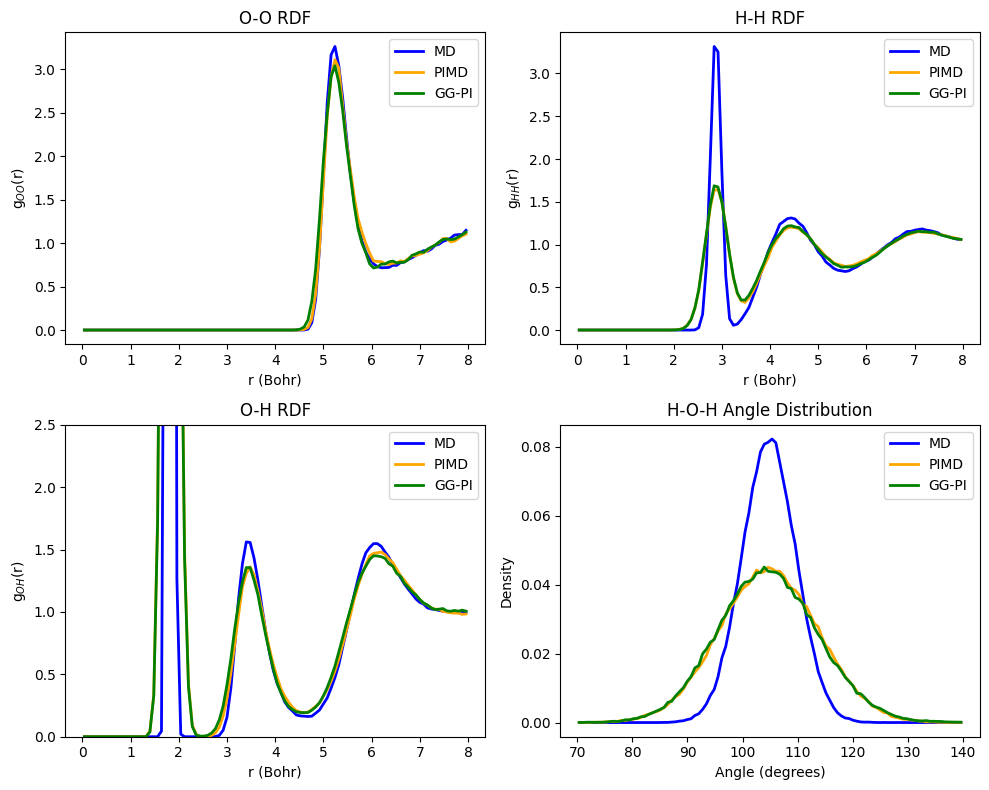

In [6]:
# =============================================================================
# Compare Results
# =============================================================================
# Calculate RDFs and angles for GG-PI samples
rdf_oo_ggpi, rdf_hh_ggpi, rdf_oh_ggpi = calculate_all_rdfs(output, Z, box_size)
angle_ggpi = calculate_hoh_angles(output, box_size)

# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].plot(rdf_oo_md[:, 0], rdf_oo_md[:, 1], 'b-', lw=2, label='MD')
axes[0, 0].plot(rdf_oo_pimd[:, 0], rdf_oo_pimd[:, 1], 'orange', lw=2, label='PIMD')
axes[0, 0].plot(rdf_oo_ggpi[:, 0], rdf_oo_ggpi[:, 1], 'g-', lw=2, label='GG-PI')
axes[0, 0].set_xlabel('r (Bohr)')
axes[0, 0].set_ylabel('g$_{OO}$(r)')
axes[0, 0].set_title('O-O RDF')
axes[0, 0].legend()

axes[0, 1].plot(rdf_hh_md[:, 0], rdf_hh_md[:, 1], 'b-', lw=2, label='MD')
axes[0, 1].plot(rdf_hh_pimd[:, 0], rdf_hh_pimd[:, 1], 'orange', lw=2, label='PIMD')
axes[0, 1].plot(rdf_hh_ggpi[:, 0], rdf_hh_ggpi[:, 1], 'g-', lw=2, label='GG-PI')
axes[0, 1].set_xlabel('r (Bohr)')
axes[0, 1].set_ylabel('g$_{HH}$(r)')
axes[0, 1].set_title('H-H RDF')
axes[0, 1].legend()

axes[1, 0].plot(rdf_oh_md[:, 0], rdf_oh_md[:, 1], 'b-', lw=2, label='MD')
axes[1, 0].plot(rdf_oh_pimd[:, 0], rdf_oh_pimd[:, 1], 'orange', lw=2, label='PIMD')
axes[1, 0].plot(rdf_oh_ggpi[:, 0], rdf_oh_ggpi[:, 1], 'g-', lw=2, label='GG-PI')
axes[1, 0].set_xlabel('r (Bohr)')
axes[1, 0].set_ylabel('g$_{OH}$(r)')
axes[1, 0].set_title('O-H RDF')
axes[1, 0].set_ylim(0, 2.5)
axes[1, 0].legend()

axes[1, 1].plot(angle_md[:, 0], angle_md[:, 1], 'b-', lw=2, label='MD')
axes[1, 1].plot(angle_pimd[:, 0], angle_pimd[:, 1], 'orange', lw=2, label='PIMD')
axes[1, 1].plot(angle_ggpi[:, 0], angle_ggpi[:, 1], 'g-', lw=2, label='GG-PI')
axes[1, 1].set_xlabel('Angle (degrees)')
axes[1, 1].set_ylabel('Density')
axes[1, 1].set_title('H-O-H Angle Distribution')
axes[1, 1].legend()

plt.tight_layout()
plt.show()